In [1]:
import pickle as pkl

import numpy as np

#### Objective
Visualize the vectors generated for MCCs.

#### Depends on:

In [ ]:
mcc_to_vector_fname = "./data/mcc_to_vector.pkl"

------

In [2]:
with open(mcc_to_vector_fname, "rb") as f:
    mcc_to_vector = pkl.load(f)

In [3]:
mccs_str = sorted(mcc_to_vector.keys())

In [4]:
mccs_idx_to_name = {i: name for i, name in enumerate(mccs_str)}
mccs_name_to_idx = {name: i for i, name in enumerate(mccs_str)}

In [5]:
len(mccs_str), len(mcc_to_vector[mccs_str[0]]["embedding"])

(434, 768)

In [6]:
source_matrix = np.zeros((len(mccs_str), len(mcc_to_vector[mccs_str[0]]["embedding"])))

In [7]:
for i, mcc_name in enumerate(mccs_str):
    source_matrix[i] = mcc_to_vector[mccs_str[i]]["embedding"]

In [8]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

In [9]:
svd = TruncatedSVD(n_components=20, n_iter=1000, random_state=42)

In [10]:
decomposed = svd.fit_transform(source_matrix)

In [11]:
embedded = TSNE(
    n_components=2, learning_rate="auto", init="random", random_state=42, perplexity=5
).fit_transform(decomposed)

In [12]:
%matplotlib widget
import matplotlib
from matplotlib import pyplot as plt

matplotlib.use("nbagg")

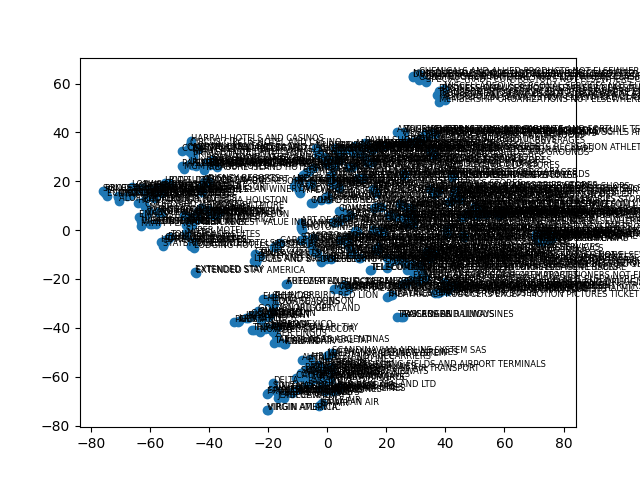

In [13]:
%matplotlib widget
x = embedded[:, 0]
y = embedded[:, 1]
tags = np.array(list(mccs_name_to_idx))

fig, ax = plt.subplots()
ax.scatter(x, y)

for i, txt in enumerate(tags):
    ax.annotate(txt, (x[i], y[i]), size=6)

plt.show()